# Data integration for human lymph node

## 1. Import Libraries and Setup Paths

In [22]:
import os
import sys

# Add parent directory to path so Python can find DeepSpak module
# In Jupyter Notebook, use os.getcwd() instead of __file__
sys.path.insert(0, os.path.dirname(os.getcwd()))

import torch
import pandas as pd
import scanpy as sc
import argparse
import numpy as np
import random

# Import DeepSpak modules
from DeepSpak.preprocess import construct_neighbor_graph,  pca,clr_normalize_each_cell
from DeepSpak.dataloder import SpatialOmicsDataLoader
from DeepSpak.utils import clustering
import DeepSpak.utils as u

# Import sklearn metrics for evaluation
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score, homogeneity_score

# Debug: print module location
print("USING UTILS:", u.__file__)
print("mclust_R SOURCE LINE:", u.mclust_R.__code__.co_firstlineno)

USING UTILS: e:\code\mymodel2\SpatialGlue\mymodel\DeepSpak\utils.py
mclust_R SOURCE LINE: 46


## 2. Define Helper Functions

In [23]:
def setup_seed(seed=42):
    """设置随机种子确保可重复性"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
setup_seed(42)

## 3. Load and Preprocess Data

In [24]:
# =============================================================================
# Load spatial multi-omics data
# =============================================================================

# Data directory path - modify this to your data location
file_fold = 'E:/code/mymodel2/data/HLN/' # Please replace 'file_fold' with the download path

adata_omics1 = sc.read_h5ad(file_fold + 'adata_RNA.h5ad')
adata_omics2 = sc.read_h5ad(file_fold + 'adata_ADT.h5ad')

adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

d:\anaconda3\envs\sedrenv\Lib\site-packages\anndata\_core\anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
d:\anaconda3\envs\sedrenv\Lib\site-packages\anndata\_core\anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 4. Configure Model Parameters

In [25]:
# =============================================================================
# Model configuration parameters
# =============================================================================

args = argparse.Namespace(
    # Training parameters
    batch_size=3484,                    # Batch size for training
    temperature_f=0.4,                  # Temperature parameter for contrastive learning
    learning_rate=0.001,                # Learning rate
    weight_decay=0.0001,                # Weight decay for regularization
    rec_epochs=200,                     # Number of reconstruction epochs
    fine_tune_epochs=100,               # Number of fine-tuning epochs
    
    # Model architecture
    low_feature_dim=512,                # Low-level feature dimension
    high_feature_dim=1024,               # High-level feature dimension
    alpha=0.5,                          # Alpha parameter for graph fusion
    walk_steps=5,                       # Number of random walk steps
    
    # Adaptive fusion settings
    use_adaptive_fusion=True,           # Whether to use adaptive fusion
    fusion_hidden_dim=128,              # Hidden dimension for fusion network
    fusion_dropout=0.2,                 # Dropout rate for fusion network
    
    # Clustering settings
    n_clusters=10,                      # Number of clusters
    feature_weight=None,                # Fusion weight for feature graph (None = adaptive)
    spatial_weight=None,                # Fusion weight for spatial graph (None = adaptive)
    
    # Data paths
    trrust_file='E:/code/mymodel2/data/HLN/trrust_rawdata.human.tsv',
    string_protein_info_file='E:/code/mymodel2/data/HLN/9606.protein.info.v12.0.txt',
    ppi_file='E:/code/mymodel2/data/HLN/9606.links.cleaned.txt',
    # Data type
    datatype='SPOTS'                    # 'SPOTS' or 'Spatial-epigenome-transcriptome'
)


### Optional: Data Imputation (Commented Out)

The following code shows how to use the SpatialOmicsDataLoader for data imputation.
This is optional and can be uncommented if needed.

In [26]:
data_loader = SpatialOmicsDataLoader(
    data_dir='E:/code/mymodel2/data/HLN/',
    trrust_file_path=args.trrust_file,
    datatype='SPOTS',
    string_protein_info_file = args.string_protein_info_file,
    ppi_file_path = args.ppi_file,
    enable_context_filtering=False
)

adata_omics1 = data_loader.impute_rna_with_grn(
    adata_omics1,
    adata_omics2,
    confidence_threshold=0.75,
    min_cells=42
)

adata_omics2= data_loader.impute_protein_with_ppi(
    adata_omics2,
    confidence_threshold=0.25,
    max_impute_rate=0.01,
    min_confidence_for_imputation=0.45,
    top_percent_to_impute=5
)

PPI network file path: E:/code/mymodel2/data/HLN/9606.links.cleaned.txt
STRING protein info file path: E:/code/mymodel2/data/HLN/9606.protein.info.v12.0.txt
Using GRN predicted data to impute raw RNA data...
First use, loading TF-gene regulatory network...
Loading TF-gene regulatory network: E:/code/mymodel2/data/HLN/trrust_rawdata.human.tsv
Original TRRUST network: 9,396 edges, 795 TFs
Skipping context gene filtering (enable_context_filtering=False)
Final TF-gene network: 795 TFs, 8427 regulatory relationships
Context gene filtering status: disabled
Found 2339 predictable genes in GRN network
Found 126 genes to impute


Imputing gene expression: 100%|██████████| 126/126 [00:00<00:00, 3954.85it/s]


Imputation statistics:
- Successfully imputed 123 genes
- Total 60389 values imputed
- Non-zero element ratio after imputation: 10.93%
Creating protein ID mapper...
从STRING数据库加载蛋白质信息: E:/code/mymodel2/data/HLN/9606.protein.info.v12.0.txt
检测到物种: human
检测到头部行，列名: ['string_protein_id', 'preferred_name', 'protein_size', 'annotation']
成功加载STRING蛋白质信息: 19699行
实际列名: ['string_protein_id', 'preferred_name']
处理了19699个蛋白质信息
创建了19699个首选名称到STRING ID的映射

示例蛋白质信息:
  ENSP00000000233: ARF5
  ENSP00000000412: M6PR
  ENSP00000001008: FKBP4
  ENSP00000001146: CYP26B1
  ENSP00000002125: NDUFAF7
STRING database loaded in mapper: 19699 proteins
从首选名称构建基因符号映射...
构建了19699个基因符号映射

示例基因符号映射:
  ARF5: ['ENSP00000000233']
  M6PR: ['ENSP00000000412']
  FKBP4: ['ENSP00000001008']
  CYP26B1: ['ENSP00000001146']
  NDUFAF7: ['ENSP00000002125']
  FUCA2: ['ENSP00000002165']
  HS3ST1: ['ENSP00000002596']
  SEMA3F: ['ENSP00000002829']
  CFTR: ['ENSP00000003084']
  CYP51A1: ['ENSP00000003100']
Saving protein ID mapper to cac

Imputing protein expression: 100%|██████████| 6/6 [00:00<00:00, 1801.68it/s]

Processing protein: CD274, STRING IDs: ['ENSP00000370989']
  ENSP00000370989 in PPI network, has 2211 interactions
  Found 26 interacting proteins in ADT data (confidence threshold >= 0.25)
  Found 26 interacting proteins, confidence threshold: 0.25
  Original zero count: 135
  High confidence zero count: 135
  Predicted non-zero count: 3483
  Fillable value count: 6
  Selected top 5% positions by predicted value, total 6
  Potential imputation rate (relative to total samples): 0.17%
  Imputed 6 values, imputation rate (relative to total samples): 0.17%
Processing protein: CEACAM8, STRING IDs: ['ENSP00000244336']
  ENSP00000244336 in PPI network, has 886 interactions
  Found 20 interacting proteins in ADT data (confidence threshold >= 0.25)
  Found 20 interacting proteins, confidence threshold: 0.25
  Original zero count: 159
  High confidence zero count: 159
  Predicted non-zero count: 3483
  Fillable value count: 7
  Selected top 5% positions by predicted value, total 7
  Potential i

## 5. Feature Extraction (PCA and LSI)

In [27]:
sc.pp.filter_genes(adata_omics1, min_cells=10)
sc.pp.highly_variable_genes(adata_omics1, flavor="seurat_v3", n_top_genes=3000)  # 选择高变异基因
sc.pp.normalize_total(adata_omics1, target_sum=1e4)  
sc.pp.log1p(adata_omics1)  
sc.pp.scale(adata_omics1)  


adata_omics1_high = adata_omics1[:, adata_omics1.var['highly_variable']]
adata_omics1.obsm['feat'] = pca(adata_omics1_high, n_comps=adata_omics2.n_vars-1)
n_comps=adata_omics2.n_vars-1
print("n_comps:",n_comps)

adata_omics2 = clr_normalize_each_cell(adata_omics2)
sc.pp.scale(adata_omics2)
adata_omics2.obsm['feat'] = pca(adata_omics2, n_comps=adata_omics2.n_vars-1)

d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:62: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


n_comps: 30


In [28]:

data = construct_neighbor_graph(adata_omics1, adata_omics2)
print("Neighbor graph constructed successfully")

Neighbor graph constructed successfully


## 6. Model Training

In [ ]:
setup_seed(42)
from DeepSpak.test_train import SpatialOmicsTrainer
trainer = SpatialOmicsTrainer(args, data)
print("Starting training...")
output = trainer.train()
print("Training completed!")

Starting training...
Pre-train Epoch 1 Loss:8.416878
Pre-train Epoch 2 Loss:8.223827
Pre-train Epoch 3 Loss:8.064817
Pre-train Epoch 4 Loss:7.917404
Pre-train Epoch 5 Loss:7.784937
Pre-train Epoch 6 Loss:7.659333
Pre-train Epoch 7 Loss:7.538088
Pre-train Epoch 8 Loss:7.420403
Pre-train Epoch 9 Loss:7.305563
Pre-train Epoch 10 Loss:7.194091
Pre-train Epoch 11 Loss:7.085992
Pre-train Epoch 12 Loss:6.981456
Pre-train Epoch 13 Loss:6.881188
Pre-train Epoch 14 Loss:6.785499
Pre-train Epoch 15 Loss:6.694360
Pre-train Epoch 16 Loss:6.607732
Pre-train Epoch 17 Loss:6.525496
Pre-train Epoch 18 Loss:6.447651
Pre-train Epoch 19 Loss:6.374223
Pre-train Epoch 20 Loss:6.305203
Pre-train Epoch 21 Loss:6.240460
Pre-train Epoch 22 Loss:6.179820
Pre-train Epoch 23 Loss:6.123129
Pre-train Epoch 24 Loss:6.070460
Pre-train Epoch 25 Loss:6.021545
Pre-train Epoch 26 Loss:5.975985
Pre-train Epoch 27 Loss:5.933448
Pre-train Epoch 28 Loss:5.893786
Pre-train Epoch 29 Loss:5.857058
Pre-train Epoch 30 Loss:5.82317

## 7. Clustering and Evaluation

In [ ]:
# =============================================================================
# Extract embeddings and perform clustering
# =============================================================================

adata = adata_omics1.copy()
adata.obsm['DeepSpak'] = output['emb_combined'].copy()

# Clustering method: 'mclust', 'leiden', or 'louvain'
tool = 'mclust'
clustering(
    adata, 
    key='DeepSpak',           
    add_key='DeepSpak',       
    n_clusters=args.n_clusters, 
    method=tool, 
    use_pca=True
)

# Calculate Adjusted Rand Index (ARI)
ari = adjusted_rand_score(adata.obs['DeepSpak'], adata.obs['ground_truth'])
print(f"Combined embedding (ARI): {ari:.6f}")

fitting ...
  |======================================================================| 100%
Combined embedding (ARI): 0.348097


In [ ]:
# =============================================================================
# Calculate additional evaluation metrics
# =============================================================================

nmi_score = normalized_mutual_info_score(adata.obs['DeepSpak'], adata.obs['ground_truth'])
ami_score = adjusted_mutual_info_score(adata.obs['DeepSpak'], adata.obs['ground_truth'])
homo_score = homogeneity_score(adata.obs['DeepSpak'], adata.obs['ground_truth'])

print(f"\nAdditional Metrics:")
print(f"  NMI (Normalized Mutual Information): {nmi_score:.6f}")
print(f"  AMI (Adjusted Mutual Information): {ami_score:.6f}")
print(f"  Homogeneity: {homo_score:.6f}")


Additional Metrics:
  NMI (Normalized Mutual Information): 0.400363
  AMI (Adjusted Mutual Information): 0.396287
  Homogeneity: 0.376937


d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
d:\anaconda3\envs\sedrenv\Lib\site-packages

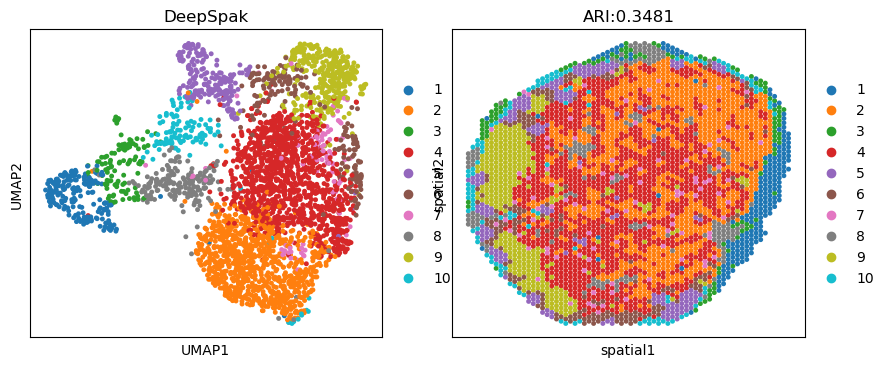

In [34]:
sc.pp.neighbors(adata, use_rep='DeepSpak')
sc.tl.umap(adata)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sc.pl.umap(adata, color='DeepSpak', ax=ax[0], s=50, show=False)
sc.pl.embedding(adata, basis='spatial', color='DeepSpak', ax=ax[1], s=50, show=False,title=f'ARI:{ari:.4f}')
plt.show()